In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.font_manager import FontProperties, fontManager

In [18]:
topks = [0.05, 0.1, 0.2]
esp_partitions = [0, 1, 0.3]

In [19]:
dfour5_esp0 = pd.read_csv(
    f"../output/our_{topks[0]}_esp_partition{esp_partitions[0]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour5_esp1 = pd.read_csv(
    f"../output/our_{topks[0]}_esp_partition{esp_partitions[1]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour5_esp03 = pd.read_csv(
    f"../output/our_{topks[0]}_esp_partition{esp_partitions[2]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)

dfour10_esp0 = pd.read_csv(
    f"../output/our_{topks[1]}_esp_partition{esp_partitions[0]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour10_esp1 = pd.read_csv(
    f"../output/our_{topks[1]}_esp_partition{esp_partitions[1]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour10_esp03 = pd.read_csv(
    f"../output/our_{topks[1]}_esp_partition{esp_partitions[2]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)

dfour20_esp0 = pd.read_csv(
    f"../output/our_{topks[2]}_esp_partition{esp_partitions[0]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour20_esp1 = pd.read_csv(
    f"../output/our_{topks[2]}_esp_partition{esp_partitions[1]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)
dfour20_esp03 = pd.read_csv(
    f"../output/our_{topks[2]}_esp_partition{esp_partitions[2]}.csv",
    header=None,
    names=["datasets", "right", "all"],
)

In [20]:
def processdf(df, whichtop, source):
    dfnew = df.copy()
    dfnew["acc"] = dfnew["right"] / dfnew["all"]
    dfnew["topk"] = whichtop
    dfnew["source"] = source
    return dfnew

In [21]:
dfour5_esp0 = processdf(dfour5_esp0, int(topks[0] * 100), "Gnina_P450")
dfour5_esp1 = processdf(dfour5_esp1, int(topks[0] * 100), "ESP_P450")
dfour5_esp03 = processdf(dfour5_esp03, int(topks[0] * 100), "Gnina_P450 + ESP_P450")

dfour10_esp0 = processdf(dfour10_esp0, int(topks[1] * 100), "Gnina_P450")
dfour10_esp1 = processdf(dfour10_esp1, int(topks[1] * 100), "ESP_P450")
dfour10_esp03 = processdf(dfour10_esp03, int(topks[1] * 100), "Gnina_P450 + ESP_P450")

dfour20_esp0 = processdf(dfour20_esp0, int(topks[2] * 100), "Gnina_P450")
dfour20_esp1 = processdf(dfour20_esp1, int(topks[2] * 100), "ESP_P450")
dfour20_esp03 = processdf(dfour20_esp03, int(topks[2] * 100), "Gnina_P450 + ESP_P450")

In [ ]:
dffinal = pd.concat(
    [
        dfour5_esp0,
        dfour5_esp1,
        dfour5_esp03,
        dfour10_esp0,
        dfour10_esp1,
        dfour10_esp03,
        dfour20_esp0,
        dfour20_esp1,
        dfour20_esp03,
    ]
)

In [23]:
dffinalgroup = dffinal.groupby(["datasets"])

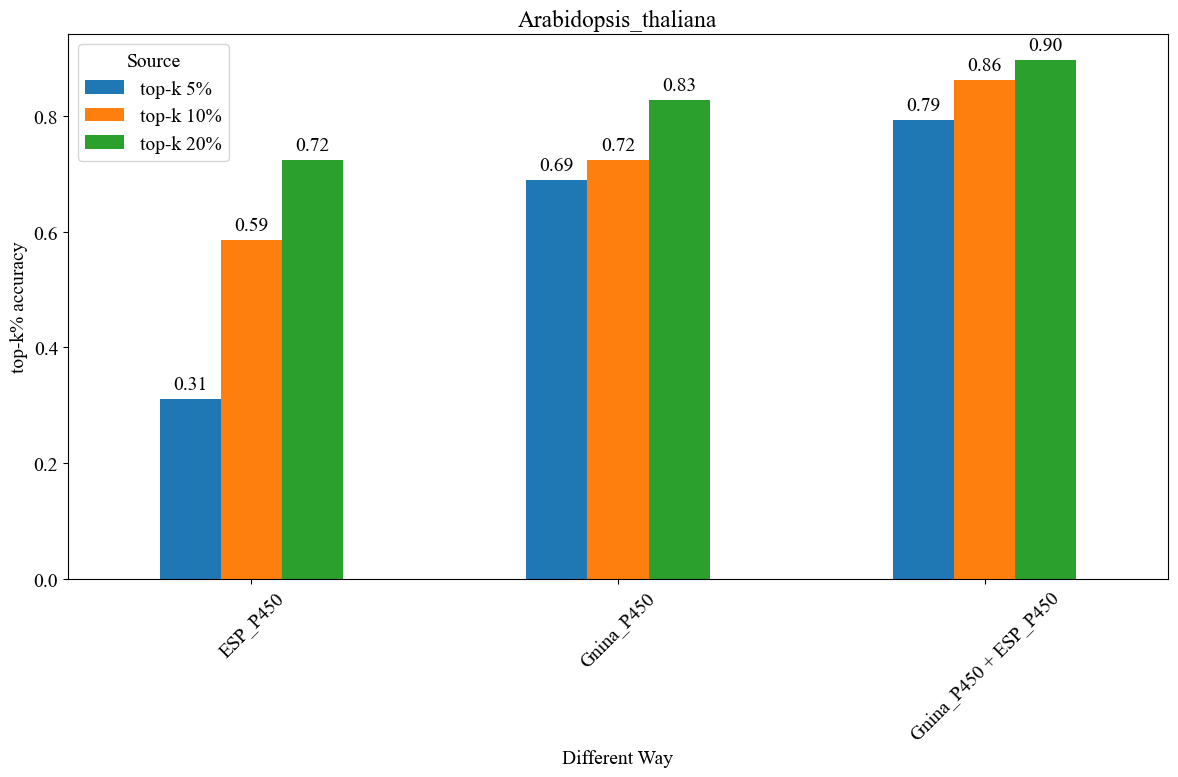

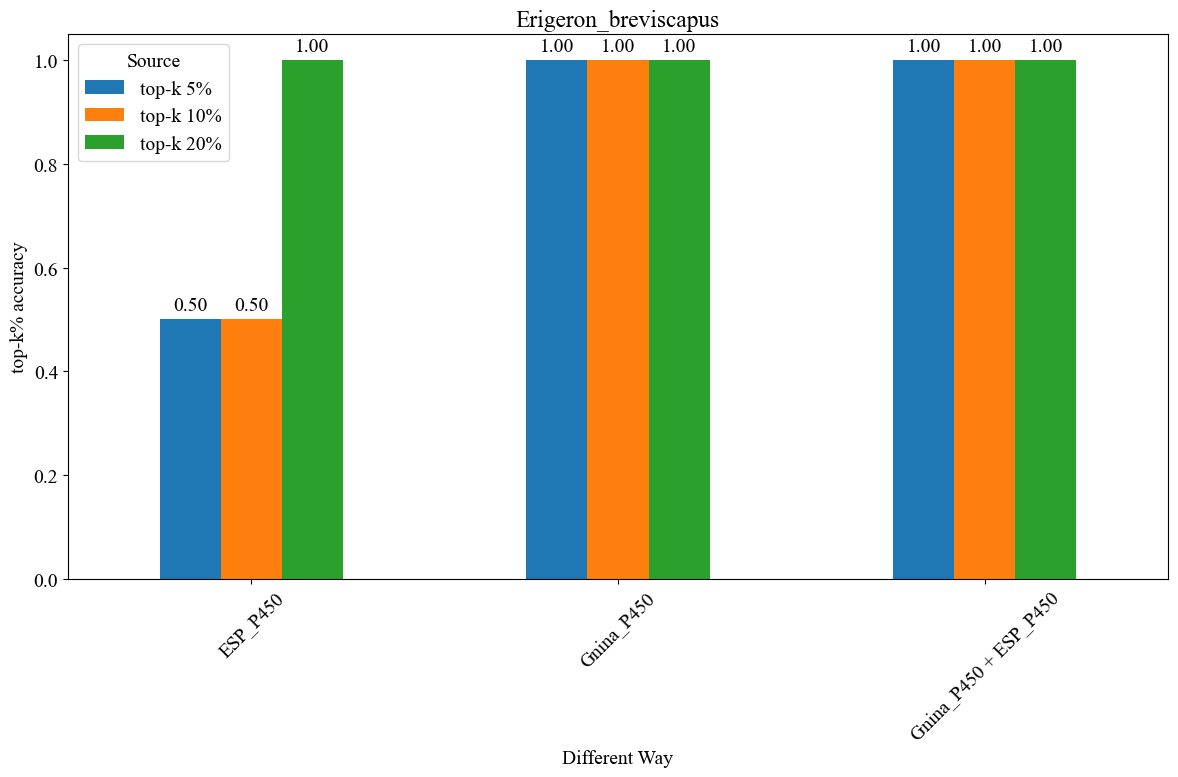

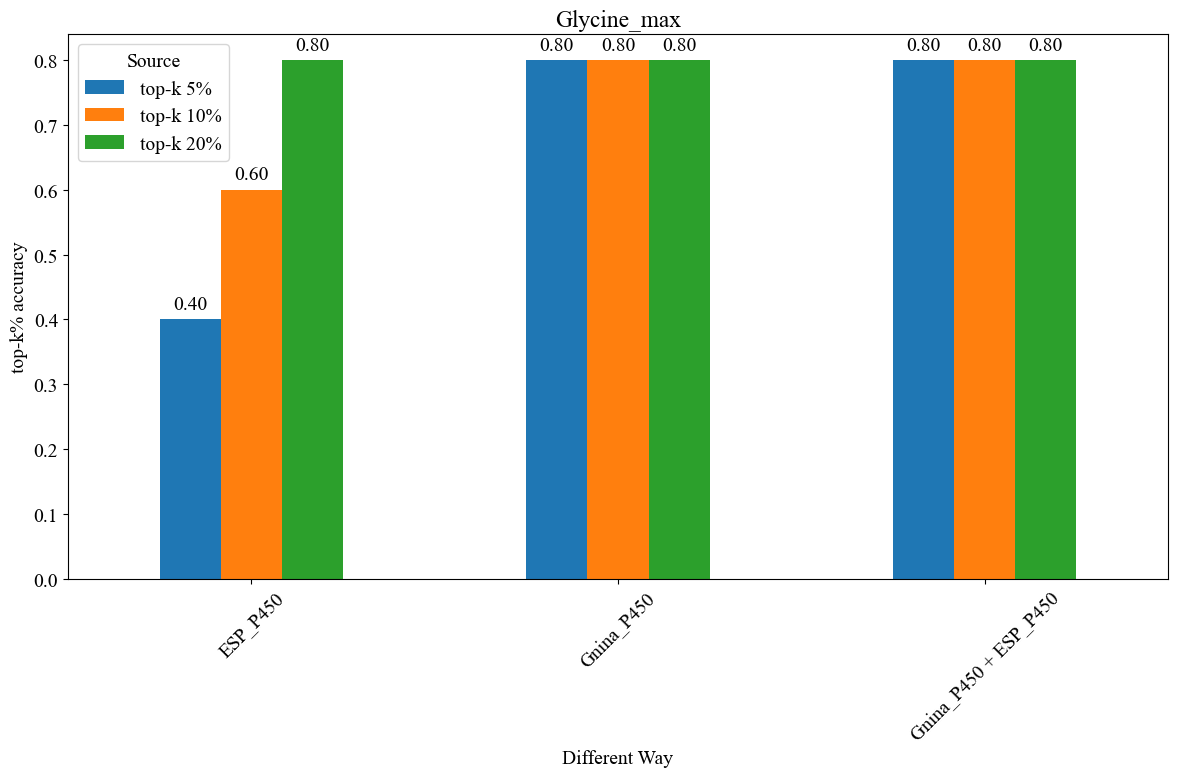

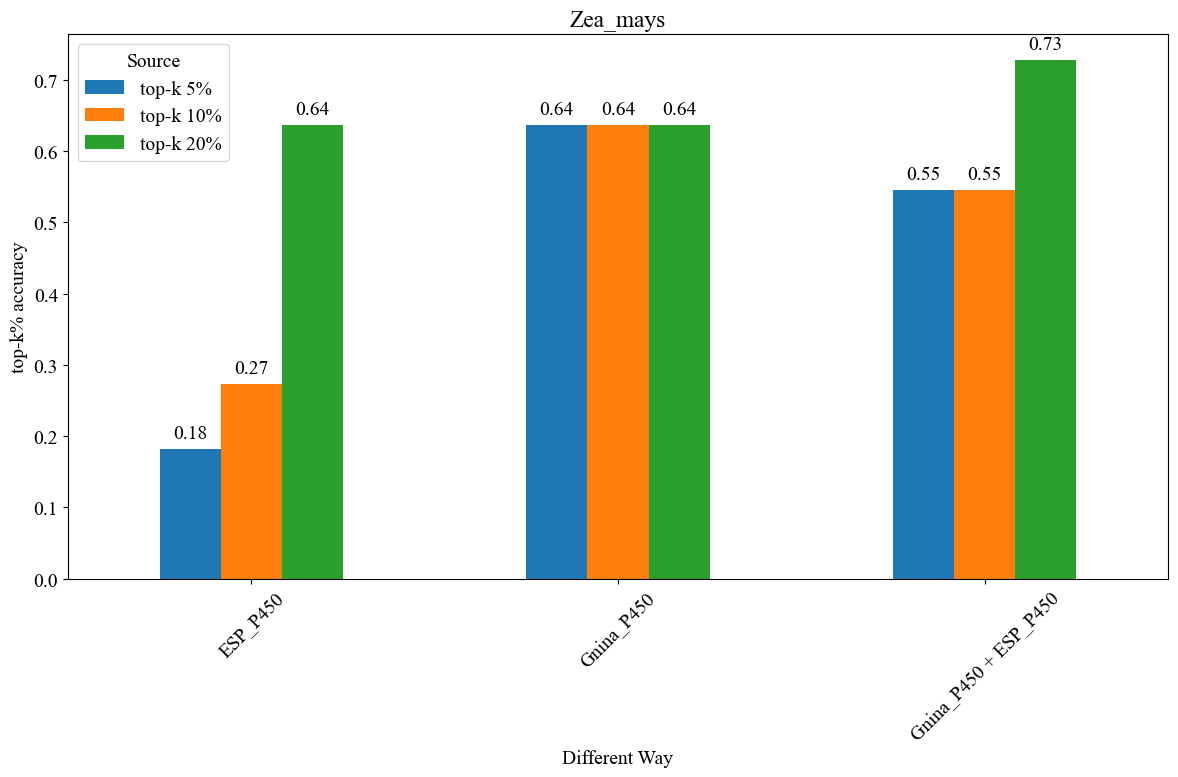

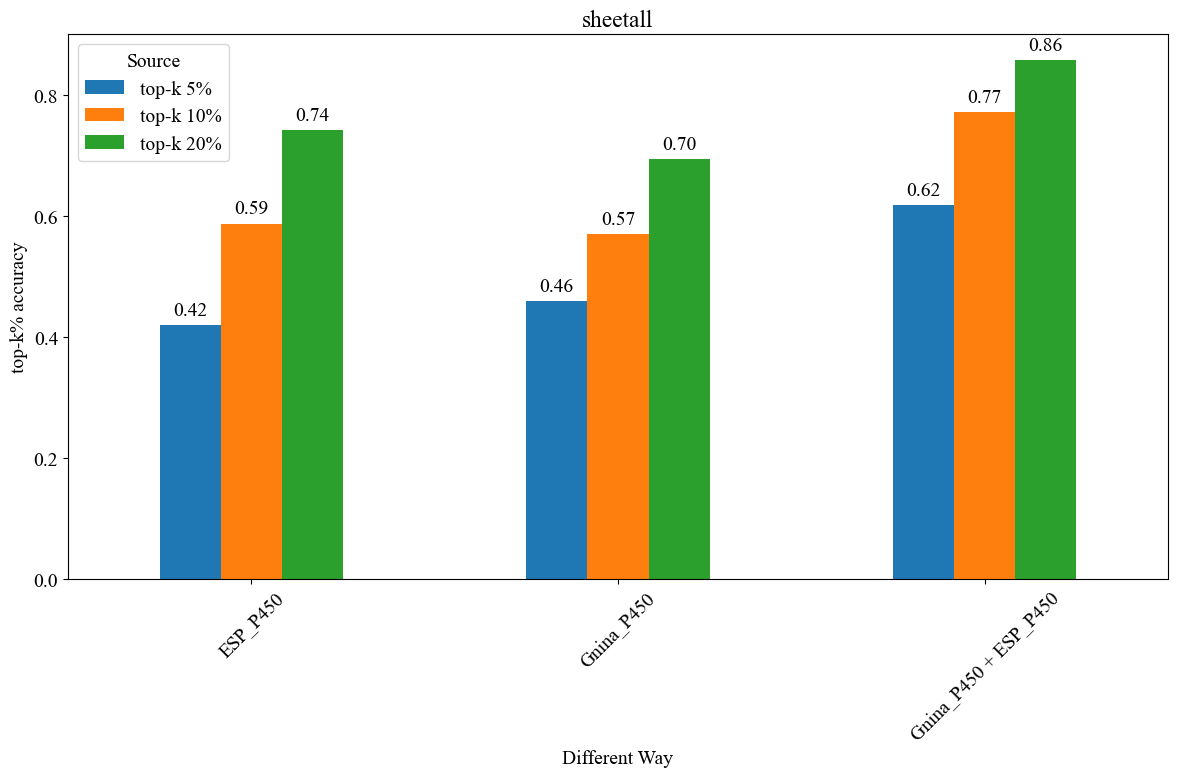

In [ ]:
font_path = "data/font/TimesNewRoman.ttf"
font_prop = FontProperties(fname=font_path, size=14)
fontManager.addfont(font_path)


font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.size"] = 14


for name, nowdff in dffinalgroup:
    fig, ax = plt.subplots(figsize=(12, 8))
    nowdff.pivot_table(index="source", columns="topk", values="acc").plot(
        kind="bar", ax=ax
    )
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.text(
                p.get_x() + p.get_width() / 2.0,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("Different Way")
    ax.set_ylabel("top-k% accuracy")
    ax.set_title(f"{name[0]}")
    plt.xticks(rotation=45)

    handles, labels = plt.gca().get_legend_handles_labels()
    labels = ["top-k " + label + "%" for label in labels]

    # plt.legend(title="Source")
    plt.legend(handles, labels, title="Source")
    plt.tight_layout()

    plt.savefig(f"../output/{name[0]}_bar_chart_esp_partition.svg")
    plt.show()